# 05 — Visuels & Stats pour publication

Figures claires, lisibles par un public sportif non-statisticien.
Chaque figure raconte une partie de l histoire.

In [2]:
import sys
sys.path.insert(0, "..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns

# Style publication
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 13,
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
})

BG = "#FAFAFA"
RED = "#E63946"
BLUE = "#457B9D"
GREEN = "#2A9D8F"
ORANGE = "#E9C46A"
DARK = "#1D3557"
GRAY = "#ADB5BD"
LIGHT_RED = "#FFCCD5"
LIGHT_GREEN = "#D8F3DC"

print("Setup OK")

Setup OK


In [3]:
# Charger les donnees
timeline = pd.read_parquet("../data/processed/timelines.parquet")
shots = pd.read_parquet("../data/processed/shots_clean.parquet")
episodes = pd.read_parquet("../data/processed/episodes.parquet")

from src.features import UnderperformanceFeatures
feat = UnderperformanceFeatures()
tl = feat.filter_complete_windows(timeline, window=10)

n_obs = len(tl)
n_matchs = tl['match_id'].nunique()
print(f"Pret : {n_obs} observations, {n_matchs} matchs")

15:34:34 │ INFO    │ Filtrage fenetre 10min : 700 obs. tronquees supprimees (10.9%)


Pret : 5706 observations, 35 matchs


---
## Figure 1 — L histoire d un match

Un match concret pour montrer ce qu est l underperformance.

In [4]:
# Trouver un match avec beaucoup d underperformance
match_stats = shots.groupby(["match_id", "team"]).agg(
    total_xg=("xg", "sum"),
    total_goals=("is_goal", "sum"),
    n_shots=("xg", "count")
).reset_index()
match_stats["underperf"] = match_stats["total_xg"] - match_stats["total_goals"]

# Equipe avec la plus grosse underperformance
best = match_stats.sort_values("underperf", ascending=False).iloc[0]
match_id = best["match_id"]
focus_team = best["team"]
match_shots = shots[shots["match_id"] == match_id]
teams = match_shots["team"].unique()
opponent = [t for t in teams if t != focus_team][0]

focus_xg = best["total_xg"]
focus_goals = int(best["total_goals"])
opp_data = match_stats[(match_stats["match_id"] == match_id) & (match_stats["team"] == opponent)].iloc[0]
opp_xg = opp_data["total_xg"]
opp_goals = int(opp_data["total_goals"])

print(f"Match : {focus_team} vs {opponent}")
print(f"{focus_team} : {focus_xg:.2f} xG, {focus_goals} but(s)")
print(f"{opponent} : {opp_xg:.2f} xG, {opp_goals} but(s)")

Match : Barcelona vs Cádiz
Barcelona : 1.53 xG, 0 but(s)
Cádiz : 2.29 xG, 2 but(s)


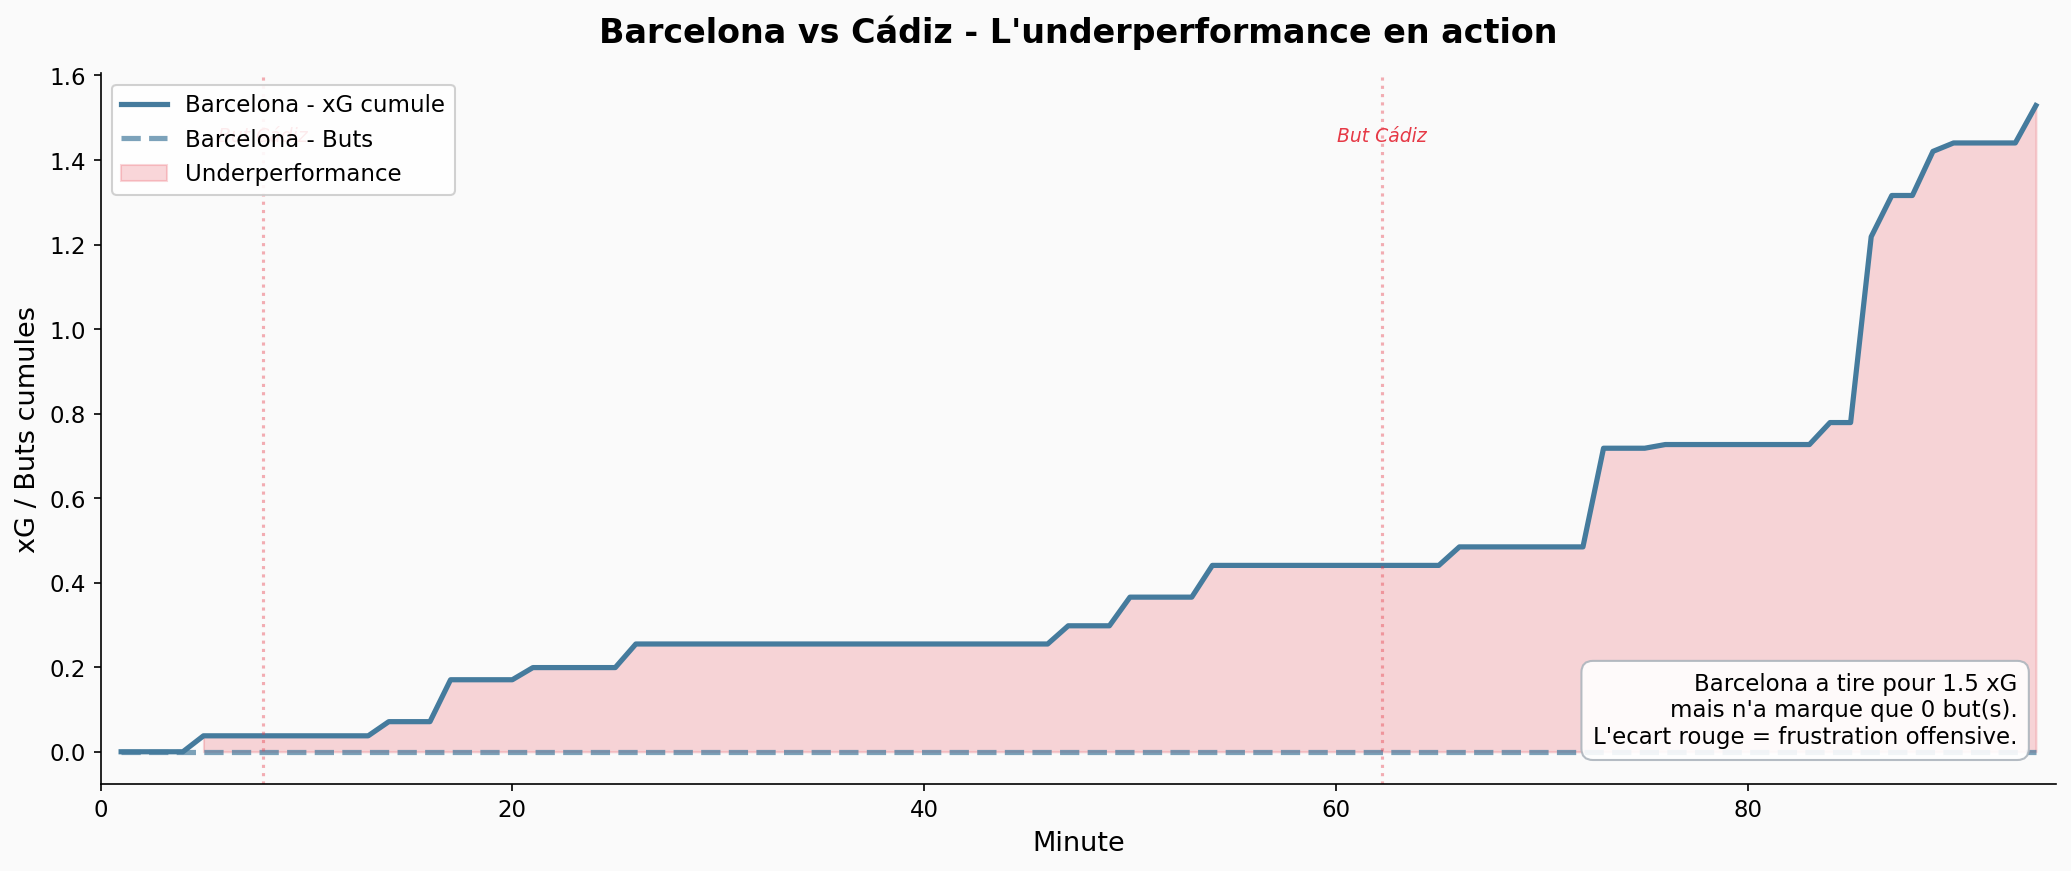

In [7]:
# Timeline du match
match_tl = timeline[timeline["match_id"] == match_id]
team_tl = match_tl[match_tl["team"] == focus_team].sort_values("minute")
opp_tl = match_tl[match_tl["team"] == opponent].sort_values("minute")

team_shots_only = match_shots[match_shots["team"] == focus_team].sort_values("game_minute")
opp_shots_only = match_shots[match_shots["team"] == opponent].sort_values("game_minute")

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

# xG cumule
ax.plot(team_tl["minute"], team_tl["cum_xg"], color=BLUE, linewidth=2.5, label=focus_team + " - xG cumule")
ax.step(team_tl["minute"], team_tl["cum_goals"], color=BLUE, linewidth=2.5, linestyle="--", alpha=0.7, label=focus_team + " - Buts", where="post")

# Zone d underperformance
ax.fill_between(team_tl["minute"], team_tl["cum_goals"], team_tl["cum_xg"],
                where=team_tl["cum_xg"] > team_tl["cum_goals"],
                alpha=0.2, color=RED, label="Underperformance")

# Buts adverses
for _, shot in opp_shots_only[opp_shots_only["is_goal"] == 1].iterrows():
    gm = shot["game_minute"]
    ax.axvline(gm, color=RED, alpha=0.4, linewidth=1.5, linestyle=":")
    ax.annotate("But " + opponent, xy=(gm, ax.get_ylim()[1] * 0.9),
               fontsize=9, color=RED, ha="center", style="italic")

ax.set_xlabel("Minute")
ax.set_ylabel("xG / Buts cumules")
ax.set_title(focus_team + " vs " + opponent + " - L'underperformance en action", pad=15)
ax.set_xlim(0, 95)
ax.legend(loc="upper left", framealpha=0.9, fontsize=11)

# Annotation narrative
note = (focus_team + " a tire pour " + str(round(focus_xg, 1)) + " xG\n"
        "mais n'a marque que " + str(focus_goals) + " but(s).\n"
        "L'ecart rouge = frustration offensive.")
ax.annotate(note, xy=(0.98, 0.05), xycoords="axes fraction", ha="right", va="bottom",
            fontsize=11, bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor=GRAY, alpha=0.9))

plt.tight_layout()
plt.savefig("../outputs/figures/pub_01_match_story.png", dpi=200, bbox_inches="tight", facecolor=BG)
plt.show()

---
## Figure 2 — Le test central

Est-ce qu une equipe qui gaspille ses occasions concede plus ?

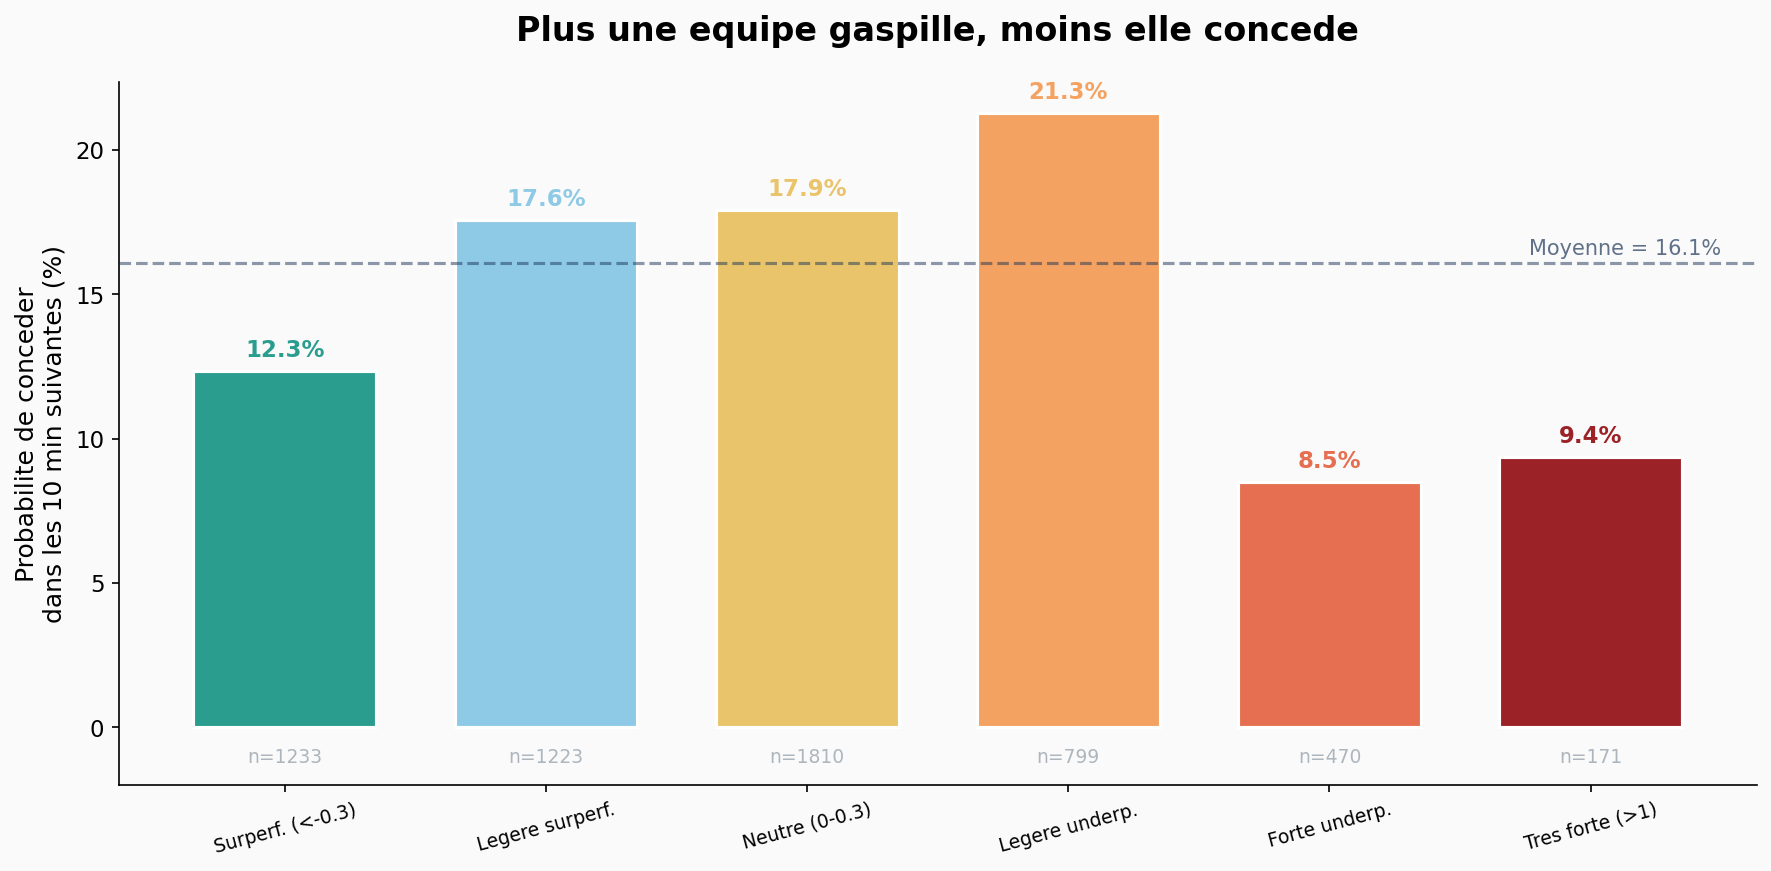

In [5]:
# Bins simples et lisibles
tl_fig = tl.copy()
bins = [-np.inf, -0.3, 0, 0.3, 0.6, 1.0, np.inf]
labels = ["Surperf. (<-0.3)", "Legere surperf.", "Neutre (0-0.3)", "Legere underp.", "Forte underp.", "Tres forte (>1)"]
tl_fig["bin"] = pd.cut(tl_fig["cum_underperf"], bins=bins, labels=labels)

stats = tl_fig.groupby("bin", observed=True).agg(
    p_concede=("future_conceded_10min", "mean"),
    n=("future_conceded_10min", "count")
).reset_index()

colors = ["#2A9D8F", "#8ECAE6", "#E9C46A", "#F4A261", "#E76F51", "#9B2226"]

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

bars = ax.bar(range(len(stats)), stats["p_concede"] * 100, color=colors[:len(stats)],
              edgecolor="white", linewidth=1.5, width=0.7)

# Baseline
baseline = tl_fig["future_conceded_10min"].mean() * 100
ax.axhline(baseline, color=DARK, linestyle="--", linewidth=1.5, alpha=0.5)
ax.text(len(stats) - 0.5, baseline + 0.3, "Moyenne = " + str(round(baseline, 1)) + "%",
        ha="right", fontsize=10, color=DARK, alpha=0.7)

ax.set_xticks(range(len(stats)))
ax.set_xticklabels(stats["bin"], fontsize=9, rotation=15)
ax.set_ylabel("Probabilite de conceder\ndans les 10 min suivantes (%)", fontsize=12)
ax.set_title("Plus une equipe gaspille, moins elle concede", pad=20)

for i, row in stats.iterrows():
    p = row["p_concede"] * 100
    n = int(row["n"])
    ax.text(i, p + 0.5, str(round(p, 1)) + "%", ha="center", fontsize=11, fontweight="bold", color=colors[i])
    ax.text(i, -1.2, "n=" + str(n), ha="center", fontsize=9, color=GRAY)

ax.set_ylim(bottom=-2)
plt.tight_layout()
plt.savefig("../outputs/figures/pub_02_central_test.png", dpi=200, bbox_inches="tight", facecolor=BG)
plt.show()

---
## Figure 3 — L'explication : c'est une question de domination

Le meme graphique mais éclaté par la situation de score.

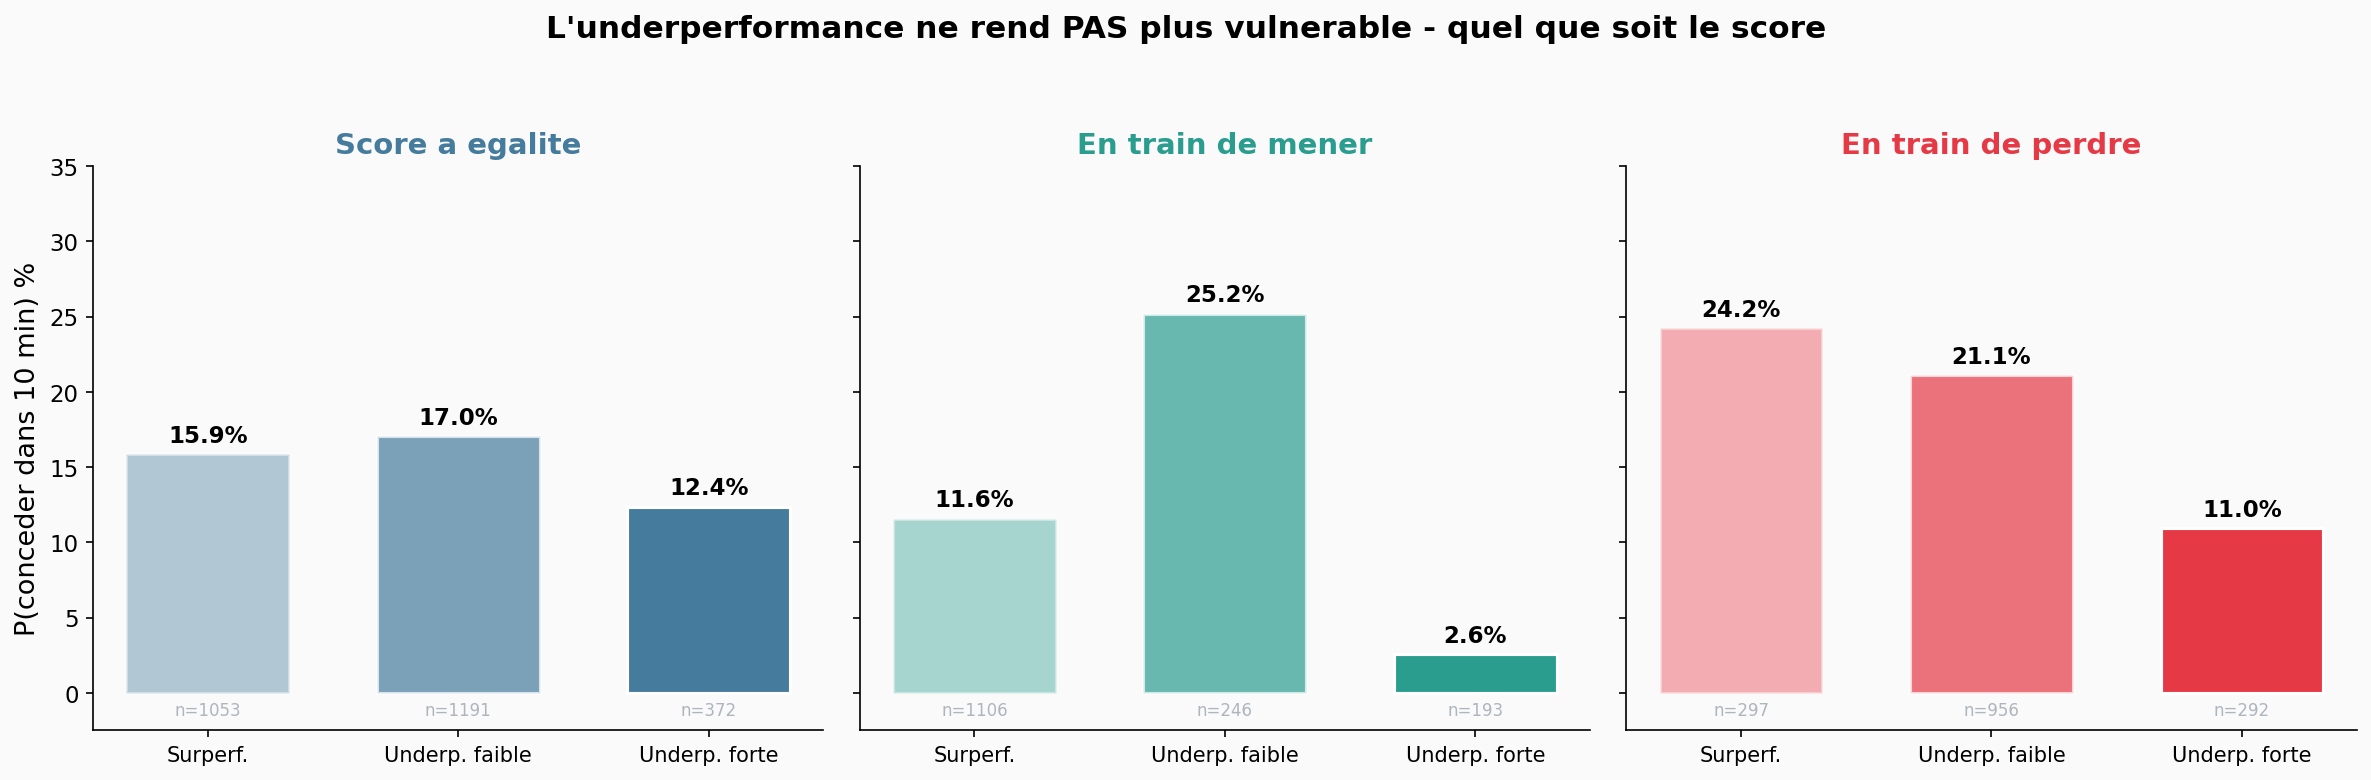

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.patch.set_facecolor(BG)

state_titles = {"drawing": "Score a egalite", "winning": "En train de mener", "losing": "En train de perdre"}
state_colors = {"drawing": BLUE, "winning": GREEN, "losing": RED}

for i, state in enumerate(["drawing", "winning", "losing"]):
    ax = axes[i]
    ax.set_facecolor(BG)
    subset = tl[tl["score_state"] == state].copy()

    bins = [-np.inf, 0, 0.5, np.inf]
    labs = ["Surperf.", "Underp. faible", "Underp. forte"]
    subset["bin"] = pd.cut(subset["cum_underperf"], bins=bins, labels=labs)

    s = subset.groupby("bin", observed=True).agg(
        p=("future_conceded_10min", "mean"),
        n=("future_conceded_10min", "count")
    ).reset_index()

    base_color = state_colors[state]
    alphas = [0.4, 0.7, 1.0]
    for j in range(len(s)):
        pval = s.iloc[j]["p"] * 100
        nval = int(s.iloc[j]["n"])
        ax.bar(j, pval, color=base_color, alpha=alphas[j],
               edgecolor="white", linewidth=1.5, width=0.65)
        ax.text(j, pval + 0.8, str(round(pval, 1)) + "%",
                ha="center", fontsize=11, fontweight="bold")
        ax.text(j, -1.5, "n=" + str(nval), ha="center", fontsize=8, color=GRAY)

    ax.set_xticks(range(len(s)))
    ax.set_xticklabels(labs, fontsize=10)
    ax.set_title(state_titles[state], fontsize=14, color=base_color, fontweight="bold")
    ax.set_ylim(bottom=-2.5, top=35)
    if i == 0:
        ax.set_ylabel("P(conceder dans 10 min) %")

fig.suptitle("L'underperformance ne rend PAS plus vulnerable - quel que soit le score",
             fontsize=15, fontweight="bold", y=1.04)
plt.tight_layout()
plt.savefig("../outputs/figures/pub_03_by_score_state.png", dpi=200, bbox_inches="tight", facecolor=BG)
plt.show()

---
## Figure 4 — Le test decisif : est-ce plus que du hasard ?

On simule 500 saisons virtuelles ou chaque tir se convertit au hasard (proba = xG).
Si le monde reel ressemble aux simulations, l effet est juste du bruit.

In [8]:
# Relancer le null model (ou charger les resultats)
from src.models import NullModelSimulation
from src.analysis import WindowAnalysis

wa = WindowAnalysis()
results_05 = wa.event_study(tl, threshold=0.5, window=10)
observed_effect = results_05["concede"]["difference"]

null = NullModelSimulation()
null_result = null.run(shots_df=shots, observed_effect=observed_effect,
                       threshold=0.5, window=10, n_simulations=500, seed=42)

print(f"Effet reel : {observed_effect:+.4f}")
nm = null_result["null_mean"]
print(f"Effet simule moyen : {nm:+.4f}")

15:39:45 │ INFO    │ Null model : 500 simulations, 35 matchs, seuil=0.5
Null model: 100%|██████████| 500/500 [01:27<00:00,  5.74it/s]

Effet reel : -0.0751
Effet simule moyen : -0.0186


In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

null_eff = null_result["null_effects"]
obs = null_result["observed_effect"]
ci = null_result["ci_95"]

# Histogramme null
ax.hist(null_eff * 100, bins=45, alpha=0.6, color=BLUE, edgecolor="white",
        density=False, label="500 saisons simulees (hasard pur)")

# Zone 95%
ax.axvspan(ci[0]*100, ci[1]*100, alpha=0.1, color=BLUE)

# Observe
ax.axvline(obs * 100, color=RED, linewidth=3, linestyle="--",
           label=f"Realite observee ({obs*100:+.1f}%)")

# Annotations
ax.annotate("Ce qu on observe
dans les vrais matchs",
            xy=(obs*100, ax.get_ylim()[1]*0.7 if ax.get_ylim()[1] > 0 else 10),
            xytext=(obs*100 - 4, ax.get_ylim()[1]*0.85 if ax.get_ylim()[1] > 0 else 12),
            fontsize=11, color=RED, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=RED, lw=1.5))

ax.set_xlabel("Difference de probabilite de conceder (traite - controle, en %)", fontsize=12)
ax.set_ylabel("Nombre de simulations", fontsize=12)
ax.set_title("Le hasard seul explique ce qu on observe", fontsize=16, fontweight="bold", pad=15)
ax.legend(fontsize=11, loc="upper right", framealpha=0.9)

# Texte explicatif
ax.text(0.02, 0.95, "Chaque barre = une saison simulee
ou les buts tombent au hasard (proba = xG).
La ligne rouge tombe dans la zone normale.
-> Pas de vrai effet.",
        transform=ax.transAxes, fontsize=10, verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.6", facecolor="white", edgecolor=GRAY, alpha=0.9))

plt.tight_layout()
plt.savefig("../outputs/figures/pub_04_null_model.png", dpi=200, bbox_inches="tight", facecolor=BG)
plt.show()

SyntaxError: EOL while scanning string literal (202400310.py, line 21)

---
## Figure 5 — Les chiffres cles

Resume visuel des resultats principaux.

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.axis("off")

# Titre
ax.text(0.5, 0.95, ""Si tu ne marques pas, tu encaisses"
Mythe ou realite ?",
        ha="center", va="top", fontsize=22, fontweight="bold", color=DARK,
        transform=ax.transAxes)

# Verdict
ax.text(0.5, 0.78, "VERDICT : MYTHE",
        ha="center", va="center", fontsize=28, fontweight="bold", color=RED,
        transform=ax.transAxes)

# Stats box
stats_data = [
    ("839", "tirs analyses", "La Liga 2020/21"),
    ("35", "matchs", "StatsBomb Open Data"),
    ("0", "variables significatives", "sur 10 testees dans la regression"),
    ("0.52", "AUC du modele predictif", "= equivalent a pile ou face"),
]

y_start = 0.62
for i, (val, label, sub) in enumerate(stats_data):
    y = y_start - i * 0.12
    ax.text(0.15, y, val, ha="center", va="center", fontsize=26, fontweight="bold",
            color=BLUE, transform=ax.transAxes)
    ax.text(0.28, y + 0.01, label, ha="left", va="center", fontsize=14,
            color=DARK, transform=ax.transAxes)
    ax.text(0.28, y - 0.03, sub, ha="left", va="center", fontsize=10,
            color=GRAY, transform=ax.transAxes)

# Conclusion
conclusion = ("Les equipes qui accumulent des occasions sans marquer
"
              "ne deviennent PAS plus vulnerables defensivement.
"
              "L effet observe s explique entierement par le hasard
"
              "et par la force des equipes dominantes.")
ax.text(0.5, 0.08, conclusion, ha="center", va="center", fontsize=13,
        color=DARK, transform=ax.transAxes, style="italic",
        bbox=dict(boxstyle="round,pad=0.8", facecolor="white", edgecolor=GRAY))

plt.savefig("../outputs/figures/pub_05_key_stats.png", dpi=200, bbox_inches="tight", facecolor=BG)
plt.show()

---
## Figure 6 — Heatmap complete

Vue d ensemble : concession par score x underperformance.

In [ ]:
tl_heat = tl.copy()
tl_heat["underperf_bin"] = pd.cut(
    tl_heat["cum_underperf"],
    bins=[-np.inf, 0, 0.3, 0.6, 1.0, np.inf],
    labels=["Surperf.", "0 a 0.3", "0.3 a 0.6", "0.6 a 1.0", "> 1.0"]
)

pivot = tl_heat.groupby(
    ["score_state", "underperf_bin"], observed=True
)["future_conceded_10min"].mean().unstack() * 100

pivot_n = tl_heat.groupby(
    ["score_state", "underperf_bin"], observed=True
)["future_conceded_10min"].count().unstack()

order = ["losing", "drawing", "winning"]
labels_fr = ["Mene au score", "Egalite", "Perd au score"]
pivot = pivot.reindex([s for s in order if s in pivot.index])
pivot_n = pivot_n.reindex([s for s in order if s in pivot_n.index])

# Annotations
annot = pivot.copy().astype(str)
for col in pivot.columns:
    for idx in pivot.index:
        try:
            v = pivot.loc[idx, col]
            n = int(pivot_n.loc[idx, col])
            if pd.notna(v):
                annot.loc[idx, col] = f"{v:.1f}%
({n} obs)"
            else:
                annot.loc[idx, col] = ""
        except:
            annot.loc[idx, col] = ""

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor(BG)

sns.heatmap(pivot, annot=annot, fmt="", cmap="YlOrRd",
            linewidths=2, linecolor="white", ax=ax,
            cbar_kws={"label": "% de chance de conceder dans 10 min"},
            vmin=0, vmax=30, annot_kws={"fontsize": 11})

ax.set_yticklabels(["Perd", "Egalite", "Mene"], rotation=0, fontsize=12)
ax.set_xlabel("Underperformance offensive (xG - Buts)", fontsize=12)
ax.set_ylabel("Situation au score", fontsize=12)
ax.set_title("Pas de pattern clair : l underperformance ne predit pas la concession",
             fontsize=14, fontweight="bold", pad=15)

plt.tight_layout()
plt.savefig("../outputs/figures/pub_06_heatmap.png", dpi=200, bbox_inches="tight", facecolor=BG)
plt.show()

---
## Recapitulatif des figures

Toutes les figures sont dans  :
1.  — Un match concret (xG vs buts)
2.  — Le test central (bar chart)
3.  — Par situation de score
4.  — Le hasard explique tout
5.  — Infographie chiffres cles
6.  — Vue d ensemble

Pretes pour Substack, Twitter, LinkedIn.